# 4. Yieldcurve fitting

## PCA 3 or 4 factors

### Change N_COMPONENTS to 3 or 4 depending on what PCA you want

In [2]:
"""
PCA Changes Matrix Generator
------------------------------
Fits rolling PCA on daily yield changes, extracts 21-day cumulative change
factors, and stores a training matrix for ANN forecasting.

Outputs: Data/Fitting/{MARKET}_PCA{PCA_NUMBER}.csv
"""

import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# ============================================
# PARAMETERS
# ============================================

MARKET        = 'DE'
N_COMPONENTS  = 3          # Number of PCA components (3 or 4)
PCA_NUMBER    = N_COMPONENTS

LOOKBACK      = 756        # Rolling window for PCA fit (trading days)
HORIZON       = 21         # Forecast horizon (trading days)
LAGS          = [22, 43, 64, 85, 106, 127, 148, 169, 190, 211]

ZERO_COLUMNS = [
    'ZERO_1Y',  'ZERO_2Y',  'ZERO_3Y',  'ZERO_4Y',  'ZERO_5Y',
    'ZERO_6Y',  'ZERO_7Y',  'ZERO_8Y',  'ZERO_9Y',  'ZERO_10Y',
    'ZERO_12Y', 'ZERO_15Y', 'ZERO_20Y', 'ZERO_25Y', 'ZERO_30Y',
]
MATURITY_NAMES = [
    '1Y', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y', '8Y',
    '9Y', '10Y', '12Y', '15Y', '20Y', '25Y', '30Y',
]

# ============================================
# LOAD DATA
# ============================================

source_path = os.path.join('Data', 'Source')
df = pd.read_csv(os.path.join(source_path, f'{MARKET}_YieldCurve.csv'))
df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'], format='ISO8601')
df = df[df['REFERENCE_DATE'].dt.dayofweek < 5].reset_index(drop=True)

print(f'Loaded {len(df)} rows  |  {df["REFERENCE_DATE"].min().date()} → {df["REFERENCE_DATE"].max().date()}')

# ============================================
# COLUMN DEFINITIONS
# ============================================

eigenval_cols = [f'EIGENVAL_{i}' for i in range(1, N_COMPONENTS + 1)]

loading_cols = [
    f'L_{mat}_PC{pc}'
    for mat in MATURITY_NAMES
    for pc  in range(1, N_COMPONENTS + 1)
]

lag_cols = []
for lag in LAGS:
    lag_cols += [f'LAG{lag}_PC{i}' for i in range(1, N_COMPONENTS + 1)]
    lag_cols += [f'RMSE_LAG{lag}']

current_cols  = [f'CURRENT_PC{i}' for i in range(1, N_COMPONENTS + 1)] + ['RMSE_CURRENT']
future_cols   = [f'FUTURE_PC{i}'  for i in range(1, N_COMPONENTS + 1)] + ['RMSE_FUTURE']
dir_diff_cols = [f'FUTURE_PC{i}_DIRECTION_DIFF' for i in range(1, N_COMPONENTS + 1)]

all_columns = (
    ['REFERENCE_DATE', 'FORECAST_DATE']
    + eigenval_cols
    + loading_cols
    + lag_cols
    + current_cols
    + future_cols
    + dir_diff_cols
)

# ============================================
# HELPER: project 21-day cumulative change
# ============================================

def project_cumulative(y_end: np.ndarray, y_start: np.ndarray, L: np.ndarray):
    """
    Compute factor representation and RMSE for the cumulative change
    (y_end - y_start) projected onto loading matrix L (m × k).
    """
    delta   = (y_end - y_start).reshape(1, -1)       # (1 × m)
    factors = (delta @ L).flatten()                   # (k,)
    recon   = factors @ L.T                           # (m,)
    rmse    = np.sqrt(np.mean((delta.flatten() - recon) ** 2))
    return factors, rmse

# ============================================
# GENERATE ROWS
# ============================================

# Earliest t requires:
#   - LOOKBACK daily changes:  indices [t-LOOKBACK, t-1] in levels → t >= LOOKBACK
#   - Oldest lag cumulative:   y_{t-max_lag-HORIZON} → t >= max(LAGS) + HORIZON = 232
#   - LOOKBACK dominates (756 > 232)
start_idx = LOOKBACK
end_idx   = len(df) - HORIZON   # need df[t + HORIZON]

n_obs = end_idx - start_idx
print(f'Generating {n_obs} observations  |  index {start_idx} → {end_idx - 1}')

levels = df[ZERO_COLUMNS].values   # pre-extract numpy array for speed

data_rows = []
for step, t in enumerate(range(start_idx, end_idx)):

    if step % max(1, n_obs // 10) == 0:
        print(f'  {step / n_obs * 100:5.1f}%  ({df.iloc[t]["REFERENCE_DATE"].date()})')

    # --------------------------------------------------
    # 1. Fit PCA on daily changes in rolling window
    # --------------------------------------------------
    window_levels  = levels[t - LOOKBACK : t]         # (LOOKBACK, 15)
    daily_changes  = np.diff(window_levels, axis=0)   # (LOOKBACK-1, 15)

    pca = PCA(n_components=N_COMPONENTS)
    pca.fit(daily_changes)

    eigenvalues = pca.explained_variance_             # (k,)
    L           = pca.components_.T                   # (15, k)

    # --------------------------------------------------
    # 2. Lag states  [projected onto L_t]
    # --------------------------------------------------
    lag_values = []
    for lag in LAGS:
        f_lag, rmse_lag = project_cumulative(
            levels[t - lag],
            levels[t - lag - HORIZON],
            L
        )
        lag_values.extend(f_lag)
        lag_values.append(rmse_lag)

    # --------------------------------------------------
    # 3. Current state: cumulative change [t-HORIZON → t]
    # --------------------------------------------------
    f_current, rmse_current = project_cumulative(levels[t], levels[t - HORIZON], L)

    # --------------------------------------------------
    # 4. Future state: cumulative change [t → t+HORIZON]
    # --------------------------------------------------
    f_future, rmse_future = project_cumulative(levels[t + HORIZON], levels[t], L)

    # --------------------------------------------------
    # 5. Direction diffs
    # --------------------------------------------------
    dir_diffs = f_future - f_current

    row = [
        df.iloc[t]['REFERENCE_DATE'],
        df.iloc[t + HORIZON]['REFERENCE_DATE'],
        *eigenvalues,
        *L.flatten(),
        *lag_values,
        *f_current, rmse_current,
        *f_future,  rmse_future,
        *dir_diffs,
    ]
    data_rows.append(row)

# ============================================
# SAVE
# ============================================

df_out = pd.DataFrame(data_rows, columns=all_columns)

output_path = os.path.join('Data', 'Fitting')
os.makedirs(output_path, exist_ok=True)
out_file = os.path.join(output_path, f'{MARKET}_PCA{PCA_NUMBER}.csv')
df_out.to_csv(out_file, index=False)

print(f'\nSaved  {df_out.shape[0]} rows × {df_out.shape[1]} cols  →  {out_file}')

Loaded 6986 rows  |  1999-01-04 → 2026-04-20
Generating 6209 observations  |  index 756 → 6964
    0.0%  (2001-11-28)
   10.0%  (2004-05-04)
   20.0%  (2006-10-02)
   30.0%  (2009-03-13)
   39.9%  (2011-08-15)
   49.9%  (2014-01-17)
   59.9%  (2016-06-21)
   69.9%  (2018-11-21)
   79.9%  (2021-04-30)
   89.9%  (2023-09-18)
   99.9%  (2026-03-03)

Saved  6209 rows × 101 cols  →  Data\Fitting\DE_PCA3.csv


In [6]:
"""
PCA Yield Curve Reconstruction
--------------------------------
Loads the PCA fitting matrix and reconstructs the yield curve on each
forecast date:
    y_{t+h} = y_t  +  f_future @ L_t^T

y_t (current levels) is pulled from the source file and merged on
REFERENCE_DATE, since the fitting matrix stores changes only.

Output: Data/Fitting/{MARKET}_RefittedPCA{PCA_NUMBER}.csv
"""

import os
import numpy as np
import pandas as pd

# ============================================
# PARAMETERS
# ============================================

MARKET     = 'DE'
PCA_NUMBER = 4    # Must match the fitting file (3 or 4)

ZERO_COLUMNS = [
    'ZERO_1Y',  'ZERO_2Y',  'ZERO_3Y',  'ZERO_4Y',  'ZERO_5Y',
    'ZERO_6Y',  'ZERO_7Y',  'ZERO_8Y',  'ZERO_9Y',  'ZERO_10Y',
    'ZERO_12Y', 'ZERO_15Y', 'ZERO_20Y', 'ZERO_25Y', 'ZERO_30Y',
]
MATURITY_NAMES = [
    '1Y', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y', '8Y',
    '9Y', '10Y', '12Y', '15Y', '20Y', '25Y', '30Y',
]

# ============================================
# LOAD
# ============================================

fitting_path = os.path.join('Data', 'Fitting')
source_path  = os.path.join('Data', 'Source')

df_fit = pd.read_csv(os.path.join(fitting_path, f'{MARKET}_PCA{PCA_NUMBER}.csv'))
df_fit['REFERENCE_DATE'] = pd.to_datetime(df_fit['REFERENCE_DATE'])
df_fit['FORECAST_DATE']  = pd.to_datetime(df_fit['FORECAST_DATE'])

# Source levels — needed for y_t
df_src = pd.read_csv(os.path.join(source_path, f'{MARKET}_YieldCurve.csv'))
df_src['REFERENCE_DATE'] = pd.to_datetime(df_src['REFERENCE_DATE'], format='ISO8601')
df_src = df_src[df_src['REFERENCE_DATE'].dt.dayofweek < 5].reset_index(drop=True)
df_src = df_src[['REFERENCE_DATE'] + ZERO_COLUMNS]

# Merge y_t onto fitting matrix
df_fit = df_fit.merge(df_src, on='REFERENCE_DATE', how='left')

print(f'Loaded {len(df_fit)} rows  |  {df_fit["FORECAST_DATE"].min().date()} → {df_fit["FORECAST_DATE"].max().date()}')

# ============================================
# RECONSTRUCT
# ============================================

# Pre-identify loading and future-factor columns
loading_cols      = [f'L_{mat}_PC{pc}'
                     for mat in MATURITY_NAMES
                     for pc  in range(1, PCA_NUMBER + 1)]
future_factor_cols = [f'FUTURE_PC{i}' for i in range(1, PCA_NUMBER + 1)]

rows = []
for _, row in df_fit.iterrows():
    L        = row[loading_cols].values.reshape(15, PCA_NUMBER)    # (15, k)
    f_future = row[future_factor_cols].values                       # (k,)
    y_t      = row[ZERO_COLUMNS].values                             # (15,)

    # y_{t+h} = y_t + change_reconstruction
    delta  = f_future @ L.T                                         # (15,)
    yields = y_t + delta                                            # (15,)

    rows.append([row['FORECAST_DATE'], *yields])

df_out = pd.DataFrame(rows, columns=['FORECAST_DATE'] + ZERO_COLUMNS)

# ============================================
# SAVE
# ============================================

out_file = os.path.join(fitting_path, f'{MARKET}_RefittedPCA{PCA_NUMBER}.csv')
df_out.to_csv(out_file, index=False)

print(f'Saved  {df_out.shape[0]} rows × {df_out.shape[1]} cols  →  {out_file}')

Loaded 6209 rows  |  2001-12-27 → 2026-04-20
Saved  6209 rows × 16 cols  →  Data\Fitting\DE_RefittedPCA4.csv


## Nelson Siegel

In [3]:
"""
Nelson-Siegel Fitting Matrix Generator
---------------------------------------
Estimates rolling optimal lambda over a 756-day window, then fits betas
for lagged, current, and future yield curves under that fixed lambda.

Outputs: Data/Fitting/{MARKET}_NS.csv
"""

import os
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ============================================
# PARAMETERS
# ============================================

MARKET   = 'DE'
LOOKBACK = 756   # Rolling window for lambda optimisation (trading days)
HORIZON  = 21    # Forecast horizon (trading days)
LAGS     = [22, 43, 64, 85, 106, 127, 148, 169, 190, 211]

ZERO_COLUMNS = [
    'ZERO_1Y',  'ZERO_2Y',  'ZERO_3Y',  'ZERO_4Y',  'ZERO_5Y',
    'ZERO_6Y',  'ZERO_7Y',  'ZERO_8Y',  'ZERO_9Y',  'ZERO_10Y',
    'ZERO_12Y', 'ZERO_15Y', 'ZERO_20Y', 'ZERO_25Y', 'ZERO_30Y',
]
MATURITIES = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30], dtype=float)

# ============================================
# LOAD DATA
# ============================================

source_path = os.path.join('Data', 'Source')
df = pd.read_csv(os.path.join(source_path, f'{MARKET}_YieldCurve.csv'))
df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'], format='ISO8601')
df = df[df['REFERENCE_DATE'].dt.dayofweek < 5].reset_index(drop=True)

print(f'Loaded {len(df)} rows  |  {df["REFERENCE_DATE"].min().date()} → {df["REFERENCE_DATE"].max().date()}')

# ============================================
# NELSON-SIEGEL HELPERS
# ============================================

def ns_loadings(lam: float) -> np.ndarray:
    """Return L(lambda) of shape (15, 3)."""
    t   = MATURITIES
    L1  = np.ones_like(t)
    exp = np.exp(-lam * t)
    L2  = (1 - exp) / (lam * t)
    L3  = L2 - exp
    return np.column_stack([L1, L2, L3])


def fit_betas(L: np.ndarray, y: np.ndarray):
    """OLS fit of betas and RMSE given fixed loadings L and yield vector y."""
    betas = np.linalg.lstsq(L, y, rcond=None)[0]
    recon = L @ betas
    rmse  = np.sqrt(np.mean((y - recon) ** 2))
    return betas, rmse


def optimise_lambda(Y_window: np.ndarray) -> float:
    """Find lambda minimising total reconstruction error over the window."""
    def objective(lam):
        if lam[0] <= 0:
            return 1e10
        try:
            L     = ns_loadings(lam[0])
            betas = np.linalg.lstsq(L, Y_window.T, rcond=None)[0]   # (3, T)
            recon = L @ betas                                          # (15, T)
            return float(np.sum((Y_window.T - recon) ** 2))
        except Exception:
            return 1e10

    result = minimize(objective, x0=[0.0609], bounds=[(0.001, 1.0)], method='L-BFGS-B')
    return float(result.x[0])

# ============================================
# COLUMN DEFINITIONS
# ============================================

lag_cols = []
for lag in LAGS:
    lag_cols += [f'LAG{lag}_BETA{i}' for i in range(1, 4)]
    lag_cols += [f'RMSE_LAG{lag}']

current_cols  = ['CURRENT_BETA1', 'CURRENT_BETA2', 'CURRENT_BETA3', 'RMSE_CURRENT']
future_cols   = ['FUTURE_BETA1',  'FUTURE_BETA2',  'FUTURE_BETA3',  'RMSE_FUTURE']
dir_diff_cols = ['FUTURE_BETA1_DIRECTION_DIFF',
                 'FUTURE_BETA2_DIRECTION_DIFF',
                 'FUTURE_BETA3_DIRECTION_DIFF']

all_columns = (
    ['REFERENCE_DATE', 'FORECAST_DATE', 'LAMBDA']
    + lag_cols
    + current_cols
    + future_cols
    + dir_diff_cols
)

# ============================================
# GENERATE ROWS
# ============================================

# start_idx = LOOKBACK: oldest lag needs levels[t - max(LAGS)] = levels[t-211]
# Since LOOKBACK=756 > 211, PCA window constraint dominates.
start_idx = LOOKBACK
end_idx   = len(df) - HORIZON   # need levels[t + HORIZON]

n_obs  = end_idx - start_idx
levels = df[ZERO_COLUMNS].values   # pre-extract for speed

print(f'Generating {n_obs} observations  |  index {start_idx} → {end_idx - 1}')

data_rows = []
for step, t in enumerate(range(start_idx, end_idx)):

    if step % max(1, n_obs // 10) == 0:
        print(f'  {step / n_obs * 100:5.1f}%  ({df.iloc[t]["REFERENCE_DATE"].date()})')

    # --------------------------------------------------
    # 1. Optimise lambda on rolling window
    # --------------------------------------------------
    Y_window  = levels[t - LOOKBACK : t]           # (756, 15)
    lam       = optimise_lambda(Y_window)
    L         = ns_loadings(lam)                   # (15, 3)

    # --------------------------------------------------
    # 2. Lag states  [all fitted with lambda_t]
    # --------------------------------------------------
    lag_values = []
    for lag in LAGS:
        betas_lag, rmse_lag = fit_betas(L, levels[t - lag])
        lag_values.extend(betas_lag)
        lag_values.append(rmse_lag)

    # --------------------------------------------------
    # 3. Current state: y_t fitted with lambda_t
    # --------------------------------------------------
    betas_current, rmse_current = fit_betas(L, levels[t])

    # --------------------------------------------------
    # 4. Future state: y_{t+HORIZON} fitted with lambda_t (stale)
    # --------------------------------------------------
    betas_future, rmse_future = fit_betas(L, levels[t + HORIZON])

    # --------------------------------------------------
    # 5. Direction diffs
    # --------------------------------------------------
    dir_diffs = betas_future - betas_current

    row = [
        df.iloc[t]['REFERENCE_DATE'],
        df.iloc[t + HORIZON]['REFERENCE_DATE'],
        lam,
        *lag_values,
        *betas_current, rmse_current,
        *betas_future,  rmse_future,
        *dir_diffs,
    ]
    data_rows.append(row)

# ============================================
# SAVE
# ============================================

df_out = pd.DataFrame(data_rows, columns=all_columns)

output_path = os.path.join('Data', 'Fitting')
os.makedirs(output_path, exist_ok=True)
out_file = os.path.join(output_path, f'{MARKET}_NS.csv')
df_out.to_csv(out_file, index=False)

print(f'\nSaved  {df_out.shape[0]} rows × {df_out.shape[1]} cols  →  {out_file}')

Loaded 6986 rows  |  1999-01-04 → 2026-04-20
Generating 6209 observations  |  index 756 → 6964
    0.0%  (2001-11-28)
   10.0%  (2004-05-04)
   20.0%  (2006-10-02)
   30.0%  (2009-03-13)
   39.9%  (2011-08-15)
   49.9%  (2014-01-17)
   59.9%  (2016-06-21)
   69.9%  (2018-11-21)
   79.9%  (2021-04-30)
   89.9%  (2023-09-18)
   99.9%  (2026-03-03)

Saved  6209 rows × 54 cols  →  Data\Fitting\DE_NS.csv


In [4]:
"""
Nelson-Siegel Yield Curve Reconstruction
-----------------------------------------
Loads the NS fitting matrix and reconstructs the yield curve on each
forecast date using the stale lambda and fitted future betas.

Output: Data/Fitting/{MARKET}_RefittedNS.csv
"""

import os
import numpy as np
import pandas as pd

# ============================================
# PARAMETERS
# ============================================

MARKET = 'DE'

MATURITIES = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30], dtype=float)
TENOR_NAMES = [
    'ZERO_1Y',  'ZERO_2Y',  'ZERO_3Y',  'ZERO_4Y',  'ZERO_5Y',
    'ZERO_6Y',  'ZERO_7Y',  'ZERO_8Y',  'ZERO_9Y',  'ZERO_10Y',
    'ZERO_12Y', 'ZERO_15Y', 'ZERO_20Y', 'ZERO_25Y', 'ZERO_30Y',
]

# ============================================
# LOAD
# ============================================

fitting_path = os.path.join('Data', 'Fitting')
df = pd.read_csv(os.path.join(fitting_path, f'{MARKET}_NS.csv'))
df['FORECAST_DATE'] = pd.to_datetime(df['FORECAST_DATE'])

print(f'Loaded {len(df)} rows  |  {df["FORECAST_DATE"].min().date()} → {df["FORECAST_DATE"].max().date()}')

# ============================================
# RECONSTRUCT
# ============================================

def ns_loadings(lam: float) -> np.ndarray:
    """Return L(lambda) of shape (15, 3)."""
    t   = MATURITIES
    exp = np.exp(-lam * t)
    L2  = (1 - exp) / (lam * t)
    return np.column_stack([np.ones_like(t), L2, L2 - exp])


rows = []
for _, row in df.iterrows():
    L    = ns_loadings(row['LAMBDA'])                                   # (15, 3)
    betas = np.array([row['FUTURE_BETA1'],
                      row['FUTURE_BETA2'],
                      row['FUTURE_BETA3']])                             # (3,)
    yields = L @ betas                                                  # (15,)

    rows.append([row['FORECAST_DATE'], *yields])

df_out = pd.DataFrame(rows, columns=['FORECAST_DATE'] + TENOR_NAMES)

# ============================================
# SAVE
# ============================================

out_file = os.path.join(fitting_path, f'{MARKET}_RefittedNS.csv')
df_out.to_csv(out_file, index=False)

print(f'Saved  {df_out.shape[0]} rows × {df_out.shape[1]} cols  →  {out_file}')

Loaded 6209 rows  |  2001-12-27 → 2026-04-20
Saved  6209 rows × 16 cols  →  Data\Fitting\DE_RefittedNS.csv


## Fitting Overview

### Stability Assesment, which fit is best

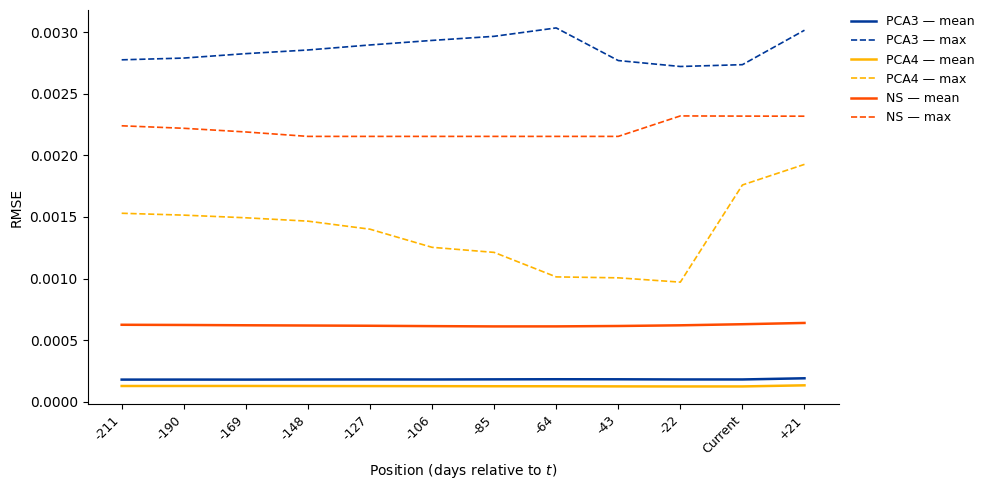


\begin{table}[htbp]
\centering
\caption{PCA3 Reconstruction RMSE by Position}
\label{tab:rmse_pca3}
\begin{tabular}{lrrrrrrr}
\hline\hline
Position & Mean & Std.\ Dev. & Min & Q25 & Median & Q75 & Max \\
\hline
-211 & 0.000181 & 0.000191 & 0.000010 & 0.000079 & 0.000124 & 0.000213 & 0.002775 \\
-190 & 0.000181 & 0.000191 & 0.000010 & 0.000079 & 0.000124 & 0.000215 & 0.002789 \\
-169 & 0.000181 & 0.000191 & 0.000010 & 0.000079 & 0.000124 & 0.000214 & 0.002825 \\
-148 & 0.000182 & 0.000193 & 0.000011 & 0.000079 & 0.000124 & 0.000215 & 0.002854 \\
-127 & 0.000182 & 0.000195 & 0.000011 & 0.000079 & 0.000125 & 0.000216 & 0.002895 \\
-106 & 0.000182 & 0.000196 & 0.000010 & 0.000079 & 0.000126 & 0.000215 & 0.002932 \\
-85 & 0.000183 & 0.000197 & 0.000010 & 0.000079 & 0.000126 & 0.000216 & 0.002965 \\
-64 & 0.000184 & 0.000200 & 0.000010 & 0.000079 & 0.000126 & 0.000218 & 0.003033 \\
-43 & 0.000183 & 0.000192 & 0.000010 & 0.000079 & 0.000126 & 0.000218 & 0.002769 \\
-22 & 0.000182 & 0.000187 

In [21]:
"""
Loading Stability Analysis
---------------------------
For each method (PCA3, PCA4, NS) plots the distribution of reconstruction
RMSE across lag positions, current, and future — expected smile shape.
Also prints a LaTeX summary table.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# PARAMETERS
# ============================================

MARKET = 'DE'
LAGS   = [22, 43, 64, 85, 106, 127, 148, 169, 190, 211]

fitting_path = os.path.join('Data', 'Fitting')

# ============================================
# LOAD FITTING DATA
# ============================================

def load_fitting(name):
    df = pd.read_csv(os.path.join(fitting_path, name))
    df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'])
    return df

pca3 = load_fitting(f'{MARKET}_PCA3.csv')
pca4 = load_fitting(f'{MARKET}_PCA4.csv')
ns   = load_fitting(f'{MARKET}_NS.csv')

# ============================================
# BUILD RMSE SERIES PER POSITION
# ============================================
# x-axis positions: lags (negative = how many days ago that window ended),
# 0 = current, +21 = future

def extract_rmse_stats(df, lags):
    """
    Returns a dict: position (int) -> dict of {mean, median, q25, q75, min, max}
    Positions: -lag for each lag, 0 for current, +21 for future.
    """
    records = {}
    for lag in lags:
        col = f'RMSE_LAG{lag}'
        s   = df[col].dropna()
        records[-lag] = dict(mean=s.mean(), median=s.median(),
                             q25=s.quantile(0.25), q75=s.quantile(0.75),
                             mn=s.min(), mx=s.max())
    for pos, col in [(0, 'RMSE_CURRENT'), (21, 'RMSE_FUTURE')]:
        s = df[col].dropna()
        records[pos] = dict(mean=s.mean(), median=s.median(),
                            q25=s.quantile(0.25), q75=s.quantile(0.75),
                            mn=s.min(), mx=s.max())
    return records

stats_pca3 = extract_rmse_stats(pca3, LAGS)
stats_pca4 = extract_rmse_stats(pca4, LAGS)
stats_ns   = extract_rmse_stats(ns,   LAGS)

# Sorted x positions
positions = sorted(stats_pca3.keys())   # same for all three

def unpack(stats, key):
    return np.array([stats[p][key] for p in positions])

# ============================================
# PLOT
# ============================================

methods = [
    ('PCA3', stats_pca3, '#003899'),
    ('PCA4', stats_pca4, '#FFB400'),
    ('NS',   stats_ns,   '#FF4B00'),
]

x_labels = [str(p) for p in positions]
x_labels[positions.index(0)]  = 'Current'
x_labels[positions.index(21)] = '+21'

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(positions))

for label, stats, color in methods:
    mean = unpack(stats, 'mean')
    mx   = unpack(stats, 'mx')
    ax.plot(x, mean, '-',  color=color, lw=1.8, label=f'{label} — mean')
    ax.plot(x, mx,   '--', color=color, lw=1.2, label=f'{label} — max')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Position (days relative to $t$)', fontsize=10)
ax.set_ylabel('RMSE', fontsize=10)
ax.legend(fontsize=9, frameon=False,
          bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================
# LATEX TABLES  (one per method, rows = positions, cols = full statistics)
# ============================================

def f(v):
    return f'{v:.6f}'

pos_labels = {p: str(p) for p in positions}
pos_labels[0]  = 'Current'
pos_labels[21] = r'$+21$'

def rmse_stats_full(df, col):
    s = df[col].dropna()
    return dict(mean=s.mean(), std=s.std(), mn=s.min(),
                q25=s.quantile(0.25), med=s.median(),
                q75=s.quantile(0.75), mx=s.max())

def col_for_position(p):
    if p == 0:  return 'RMSE_CURRENT'
    if p == 21: return 'RMSE_FUTURE'
    return f'RMSE_LAG{abs(p)}'

tables = [
    ('PCA3', pca3, r'PCA3 Reconstruction RMSE by Position', 'tab:rmse_pca3'),
    ('PCA4', pca4, r'PCA4 Reconstruction RMSE by Position', 'tab:rmse_pca4'),
    ('NS',   ns,   r'NS Reconstruction RMSE by Position',   'tab:rmse_ns'),
]

for method, df_, caption, label in tables:
    print()
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    print(rf'\caption{{{caption}}}')
    print(rf'\label{{{label}}}')
    print(r'\begin{tabular}{lrrrrrrr}')
    print(r'\hline\hline')
    print(r'Position & Mean & Std.\ Dev. & Min & Q25 & Median & Q75 & Max \\')
    print(r'\hline')
    for p in positions:
        st = rmse_stats_full(df_, col_for_position(p))
        print(f'{pos_labels[p]} & {f(st["mean"])} & {f(st["std"])} & {f(st["mn"])} & '
              f'{f(st["q25"])} & {f(st["med"])} & {f(st["q75"])} & {f(st["mx"])} \\\\')
    print(r'\hline\hline')
    print(r'\end{tabular}')
    print(r'\end{table}')

### Yield fit assesment based on reconstruction

Aligned observations: 6209


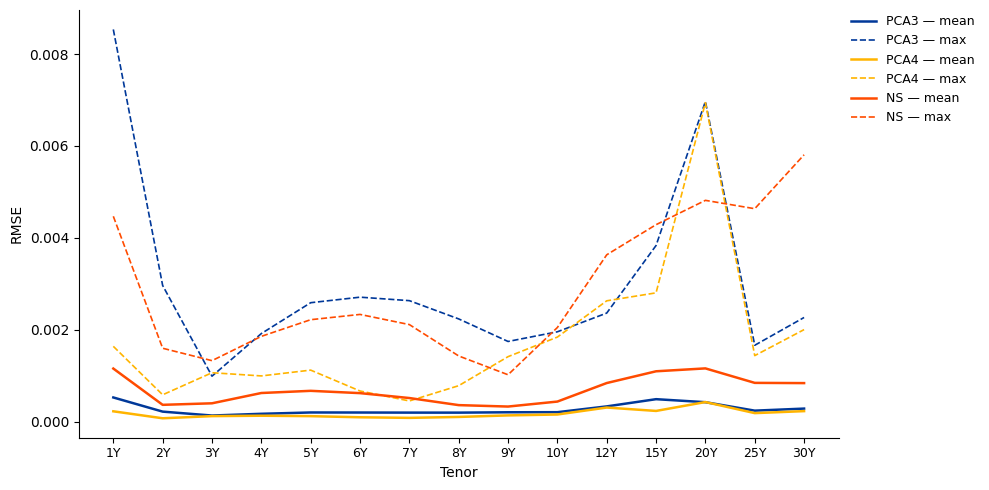


\begin{table}[htbp]
\centering
\caption{PCA3 Reconstruction Errors by Tenor}
\label{tab:recon_pca3}
\begin{tabular}{lrrrrrrr}
\hline\hline
Tenor & Mean & Std.\ Dev. & Min & Q25 & Median & Q75 & Max \\
\hline
1Y & 0.000528 & 0.000463 & 0.000000 & 0.000059 & 0.000135 & 0.000285 & 0.008535 \\
2Y & 0.000220 & 0.000192 & 0.000000 & 0.000022 & 0.000050 & 0.000120 & 0.002964 \\
3Y & 0.000135 & 0.000103 & 0.000000 & 0.000027 & 0.000057 & 0.000107 & 0.000991 \\
4Y & 0.000172 & 0.000136 & 0.000000 & 0.000032 & 0.000070 & 0.000134 & 0.001918 \\
5Y & 0.000201 & 0.000163 & 0.000000 & 0.000032 & 0.000074 & 0.000147 & 0.002590 \\
6Y & 0.000200 & 0.000168 & 0.000000 & 0.000028 & 0.000063 & 0.000134 & 0.002710 \\
7Y & 0.000198 & 0.000171 & 0.000000 & 0.000023 & 0.000054 & 0.000113 & 0.002634 \\
8Y & 0.000198 & 0.000167 & 0.000000 & 0.000026 & 0.000057 & 0.000121 & 0.002237 \\
9Y & 0.000206 & 0.000166 & 0.000000 & 0.000031 & 0.000075 & 0.000146 & 0.001746 \\
10Y & 0.000208 & 0.000163 & 0.000000 & 0.000

In [20]:
"""
Reconstruction Error Analysis
-------------------------------
For each method (NS, PCA3, PCA4) computes per-tenor absolute forecast errors
against actual yields, then plots mean and max across tenors and prints
three LaTeX summary tables.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# PARAMETERS
# ============================================

MARKET = 'DE'

ZERO_COLUMNS = [
    'ZERO_1Y',  'ZERO_2Y',  'ZERO_3Y',  'ZERO_4Y',  'ZERO_5Y',
    'ZERO_6Y',  'ZERO_7Y',  'ZERO_8Y',  'ZERO_9Y',  'ZERO_10Y',
    'ZERO_12Y', 'ZERO_15Y', 'ZERO_20Y', 'ZERO_25Y', 'ZERO_30Y',
]
TENOR_LABELS = ['1Y','2Y','3Y','4Y','5Y','6Y','7Y','8Y','9Y','10Y',
                '12Y','15Y','20Y','25Y','30Y']

fitting_path = os.path.join('Data', 'Fitting')
source_path  = os.path.join('Data', 'Source')

# ============================================
# LOAD
# ============================================

def _load(name, date_col):
    df = pd.read_csv(os.path.join(fitting_path, name))
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[ZERO_COLUMNS]

ns   = _load(f'{MARKET}_RefittedNS.csv',   'FORECAST_DATE')
pca3 = _load(f'{MARKET}_RefittedPCA3.csv', 'FORECAST_DATE')
pca4 = _load(f'{MARKET}_RefittedPCA4.csv', 'FORECAST_DATE')

actual = pd.read_csv(os.path.join(source_path, f'{MARKET}_YieldCurve.csv'))
actual['REFERENCE_DATE'] = pd.to_datetime(actual['REFERENCE_DATE'], format='ISO8601')
actual = actual.set_index('REFERENCE_DATE')[ZERO_COLUMNS]

# Align all on common forecast dates
common = ns.index.intersection(pca3.index).intersection(pca4.index).intersection(actual.index)
ns     = ns.loc[common]
pca3   = pca3.loc[common]
pca4   = pca4.loc[common]
act    = actual.loc[common]

print(f'Aligned observations: {len(common)}')

# ============================================
# COMPUTE PER-TENOR ERRORS
# ============================================
# squared errors shape: (n_dates, 15)

sq_errors = {
    'NS':   (ns   - act) ** 2,
    'PCA3': (pca3 - act) ** 2,
    'PCA4': (pca4 - act) ** 2,
}

# Per-tenor stats across dates.
# mean = true RMSE: sqrt(mean(sq_errors)) across all dates.
# Distribution stats (std, quantiles, max) use per-date absolute errors.
def tenor_stats(sq_df):
    abs_df = sq_df ** 0.5
    return {
        'mean': sq_df.mean() ** 0.5,
        'std':  abs_df.std(),
        'mn':   abs_df.min(),
        'q25':  abs_df.quantile(0.25),
        'med':  abs_df.median(),
        'q75':  abs_df.quantile(0.75),
        'mx':   abs_df.max(),
    }

stats = {m: tenor_stats(e) for m, e in sq_errors.items()}

# ============================================
# PLOT
# ============================================

methods = [
    ('PCA3', '#003899'),
    ('PCA4', '#FFB400'),
    ('NS',   '#FF4B00'),
]

x = np.arange(len(TENOR_LABELS))

fig, ax = plt.subplots(figsize=(10, 5))

for label, color in methods:
    mean = stats[label]['mean'].values
    mx   = stats[label]['mx'].values
    ax.plot(x, mean, '-',  color=color, lw=1.8, label=f'{label} — mean')
    ax.plot(x, mx,   '--', color=color, lw=1.2, label=f'{label} — max')

ax.set_xticks(x)
ax.set_xticklabels(TENOR_LABELS, fontsize=9)
ax.set_xlabel('Tenor', fontsize=10)
ax.set_ylabel('RMSE', fontsize=10)
ax.legend(fontsize=9, frameon=False,
          bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================
# LATEX TABLES  (one per method)
# ============================================

def f(v):
    return f'{v:.6f}'

tables = [
    ('PCA3', r'PCA3 Reconstruction Errors by Tenor', 'tab:recon_pca3'),
    ('PCA4', r'PCA4 Reconstruction Errors by Tenor', 'tab:recon_pca4'),
    ('NS',   r'NS Reconstruction Errors by Tenor',   'tab:recon_ns'),
]

for method, caption, label in tables:
    st = stats[method]
    print()
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    print(rf'\caption{{{caption}}}')
    print(rf'\label{{{label}}}')
    print(r'\begin{tabular}{lrrrrrrr}')
    print(r'\hline\hline')
    print(r'Tenor & Mean & Std.\ Dev. & Min & Q25 & Median & Q75 & Max \\')
    print(r'\hline')
    for tenor in ZERO_COLUMNS:
        tl = TENOR_LABELS[ZERO_COLUMNS.index(tenor)]
        print(f'{tl} & {f(st["mean"][tenor])} & {f(st["std"][tenor])} & '
              f'{f(st["mn"][tenor])} & {f(st["q25"][tenor])} & '
              f'{f(st["med"][tenor])} & {f(st["q75"][tenor])} & '
              f'{f(st["mx"][tenor])} \\\\')
    print(r'\hline\hline')
    print(r'\end{tabular}')
    print(r'\end{table}')

### Time series fit analysis

Aligned observations: 6209


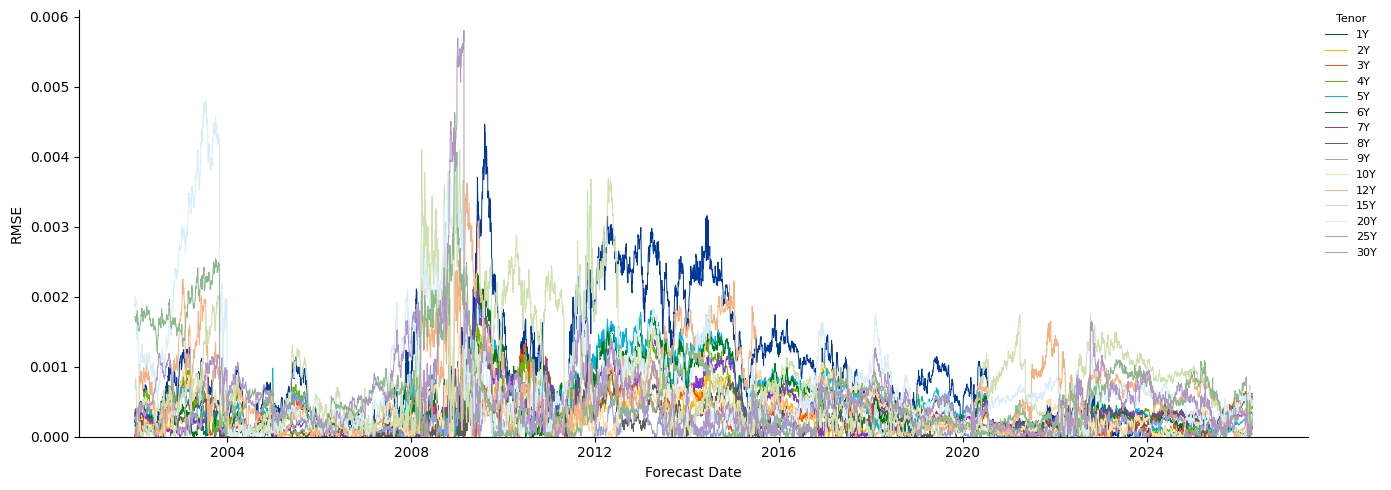


Top 3 largest errors — NS
Tenor   Rank   Date          RMSE
------------------------------------------
1Y      1      2009-08-07    0.004470
        2      2009-08-10    0.004441
        3      2009-08-12    0.004336
2Y      1      2009-06-01    0.001599
        2      2009-06-02    0.001579
        3      2009-08-12    0.001521
3Y      1      2010-06-28    0.001329
        2      2010-06-24    0.001322
        3      2010-06-25    0.001318
4Y      1      2009-08-07    0.001857
        2      2009-08-10    0.001806
        3      2009-08-12    0.001736
5Y      1      2009-08-07    0.002220
        2      2009-06-11    0.002200
        3      2009-08-10    0.002193
6Y      1      2009-06-11    0.002335
        2      2009-06-12    0.002330
        3      2009-06-18    0.002301
7Y      1      2009-06-11    0.002113
        2      2009-06-12    0.002097
        3      2009-06-10    0.002034
8Y      1      2009-06-02    0.001431
        2      2009-06-01    0.001394
        3      2009-05

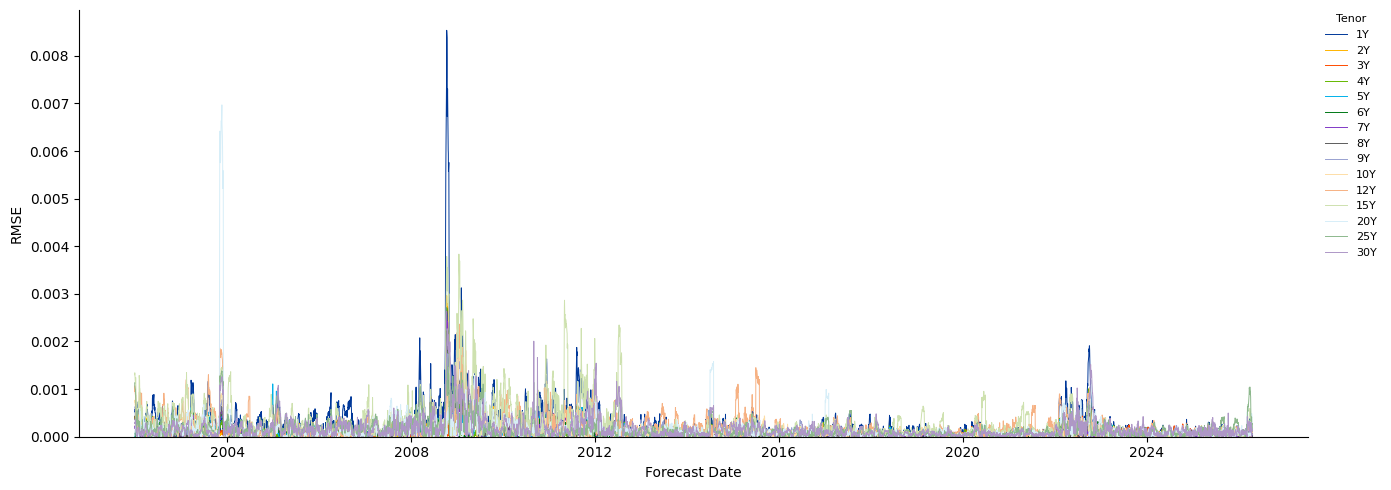


Top 3 largest errors — PCA3
Tenor   Rank   Date          RMSE
------------------------------------------
1Y      1      2008-10-10    0.008535
        2      2008-10-13    0.008376
        3      2008-10-14    0.007943
2Y      1      2008-10-10    0.002964
        2      2008-10-08    0.002796
        3      2008-10-16    0.002790
3Y      1      2009-01-15    0.000991
        2      2022-10-03    0.000922
        3      2009-01-27    0.000922
4Y      1      2008-10-13    0.001918
        2      2008-10-14    0.001885
        3      2008-10-10    0.001878
5Y      1      2008-10-10    0.002590
        2      2008-10-13    0.002560
        3      2008-10-14    0.002526
6Y      1      2008-10-10    0.002710
        2      2008-10-13    0.002620
        3      2008-10-14    0.002545
7Y      1      2008-10-10    0.002634
        2      2008-10-08    0.002491
        3      2008-10-13    0.002486
8Y      1      2008-10-10    0.002237
        2      2008-10-20    0.002230
        3      2008-

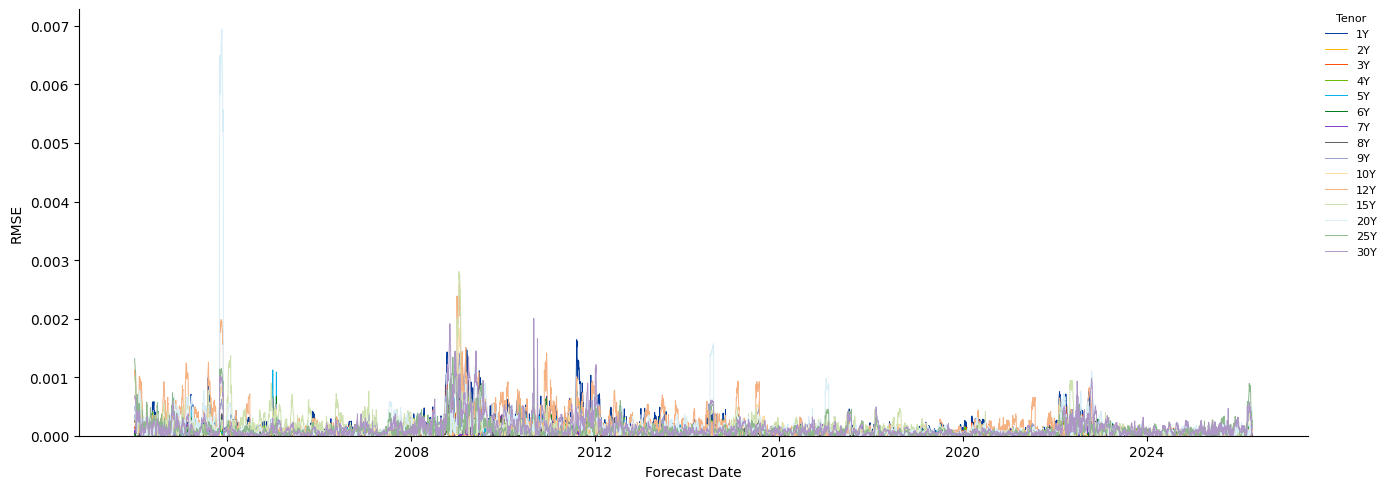


Top 3 largest errors — PCA4
Tenor   Rank   Date          RMSE
------------------------------------------
1Y      1      2011-08-09    0.001640
        2      2011-08-11    0.001613
        3      2011-08-10    0.001521
2Y      1      2008-10-13    0.000586
        2      2005-01-26    0.000559
        3      2004-12-28    0.000529
3Y      1      2008-10-13    0.001066
        2      2008-10-10    0.001052
        3      2009-01-15    0.001022
4Y      1      2009-01-15    0.000997
        2      2009-01-27    0.000966
        3      2009-01-23    0.000966
5Y      1      2004-12-28    0.001123
        2      2005-01-26    0.001087
        3      2009-01-28    0.000829
6Y      1      2005-01-26    0.000669
        2      2004-12-28    0.000637
        3      2010-12-09    0.000634
7Y      1      2010-12-13    0.000452
        2      2010-12-09    0.000430
        3      2010-12-03    0.000428
8Y      1      2009-01-26    0.000784
        2      2009-01-27    0.000766
        3      2009-

: 

In [ ]:
"""
Reconstruction Error Time Series
----------------------------------
For each method (NS, PCA3, PCA4) plots the absolute forecast error
per tenor over time. One subplot per method, 15 coloured lines per plot.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# PARAMETERS
# ============================================

MARKET = 'DE'

ZERO_COLUMNS = [
    'ZERO_1Y',  'ZERO_2Y',  'ZERO_3Y',  'ZERO_4Y',  'ZERO_5Y',
    'ZERO_6Y',  'ZERO_7Y',  'ZERO_8Y',  'ZERO_9Y',  'ZERO_10Y',
    'ZERO_12Y', 'ZERO_15Y', 'ZERO_20Y', 'ZERO_25Y', 'ZERO_30Y',
]
TENOR_LABELS = [
    '1Y', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y', '8Y', '9Y', '10Y',
    '12Y', '15Y', '20Y', '25Y', '30Y',
]
ECB_COLORS = [
    '#003899', '#FFB400', '#FF4B00', '#65B800', '#00B1EA',
    '#007816', '#8139C6', '#5C5C5C', '#98A1D0', '#FDDDA7',
    '#F6B183', '#CEE1AF', '#D7EEF8', '#8DB88D', '#AE97C7',
]

fitting_path = os.path.join('Data', 'Fitting')
source_path  = os.path.join('Data', 'Source')

# ============================================
# LOAD
# ============================================

def _load(name, date_col):
    df = pd.read_csv(os.path.join(fitting_path, name))
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[ZERO_COLUMNS]

ns   = _load(f'{MARKET}_RefittedNS.csv',   'FORECAST_DATE')
pca3 = _load(f'{MARKET}_RefittedPCA3.csv', 'FORECAST_DATE')
pca4 = _load(f'{MARKET}_RefittedPCA4.csv', 'FORECAST_DATE')

actual = pd.read_csv(os.path.join(source_path, f'{MARKET}_YieldCurve.csv'))
actual['REFERENCE_DATE'] = pd.to_datetime(actual['REFERENCE_DATE'], format='ISO8601')
actual = actual.set_index('REFERENCE_DATE')[ZERO_COLUMNS]

# Align on common dates
common = ns.index.intersection(pca3.index).intersection(pca4.index).intersection(actual.index)
ns     = ns.loc[common]
pca3   = pca3.loc[common]
pca4   = pca4.loc[common]
act    = actual.loc[common]

print(f'Aligned observations: {len(common)}')

# ============================================
# COMPUTE ABSOLUTE ERRORS
# ============================================

errors = {
    'NS':   (ns   - act).abs(),
    'PCA3': (pca3 - act).abs(),
    'PCA4': (pca4 - act).abs(),
}

# ============================================
# PLOT + SUMMARY — one figure per method
# ============================================

methods = ['NS', 'PCA3', 'PCA4']

# Use squared errors for consistency with RMSE framing
sq_errors = {m: (e ** 2) for m, e in errors.items()}   # still per-date per-tenor

for method in methods:

    # --- figure ---
    fig, ax = plt.subplots(figsize=(14, 5))

    for col, label, color in zip(ZERO_COLUMNS, TENOR_LABELS, ECB_COLORS):
        # sqrt(squared_error) = |error| per date, labelled RMSE for consistency
        ax.plot(errors[method].index,
                sq_errors[method][col] ** 0.5,
                lw=0.7, color=color, label=label)

    ax.set_xlabel('Forecast Date', fontsize=10)
    ax.set_ylabel('RMSE', fontsize=10)
    ax.set_ylim(bottom=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, frameon=False,
              bbox_to_anchor=(1.01, 1), loc='upper left',
              borderaxespad=0, title='Tenor', title_fontsize=8)

    plt.tight_layout()
    plt.show()
    plt.close()

    # --- top-3 summary per tenor ---
    print(f'\nTop 3 largest errors — {method}')
    print(f'{"Tenor":<6}  {"Rank":<5}  {"Date":<12}  {"RMSE"}')
    print('-' * 42)
    for col, label in zip(ZERO_COLUMNS, TENOR_LABELS):
        top3 = errors[method][col].nlargest(3)
        for rank, (date, val) in enumerate(top3.items(), 1):
            date_str = date.strftime('%Y-%m-%d')
            tenor_str = label if rank == 1 else ''
            print(f'{tenor_str:<6}  {rank:<5}  {date_str:<12}  {val:.6f}')
    print()

### Plotter

In [22]:
"""
Yield Curve Fit Visualiser
---------------------------
Loads refitted yield curves (NS, PCA3, PCA4) and actual yields,
then plots them for any forecast date.

Usage:
    plot_fit('2019-03-15')
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# PARAMETERS
# ============================================

MARKET = 'DE'

MATURITIES   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]
ZERO_COLUMNS = [
    'ZERO_1Y',  'ZERO_2Y',  'ZERO_3Y',  'ZERO_4Y',  'ZERO_5Y',
    'ZERO_6Y',  'ZERO_7Y',  'ZERO_8Y',  'ZERO_9Y',  'ZERO_10Y',
    'ZERO_12Y', 'ZERO_15Y', 'ZERO_20Y', 'ZERO_25Y', 'ZERO_30Y',
]

# ============================================
# LOAD DATA
# ============================================

fitting_path = os.path.join('Data', 'Fitting')
source_path  = os.path.join('Data', 'Source')

def _load(name, date_col):
    df = pd.read_csv(os.path.join(fitting_path, name))
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)

ns   = _load(f'{MARKET}_RefittedNS.csv',   'FORECAST_DATE')
pca3 = _load(f'{MARKET}_RefittedPCA3.csv', 'FORECAST_DATE')
pca4 = _load(f'{MARKET}_RefittedPCA4.csv', 'FORECAST_DATE')

actual = pd.read_csv(os.path.join(source_path, f'{MARKET}_YieldCurve.csv'))
actual['REFERENCE_DATE'] = pd.to_datetime(actual['REFERENCE_DATE'], format='ISO8601')
actual = actual.set_index('REFERENCE_DATE')

print(f'NS:     {len(ns)} dates')
print(f'PCA3:   {len(pca3)} dates')
print(f'PCA4:   {len(pca4)} dates')
print(f'Actual: {len(actual)} dates')

# ============================================
# PLOT FUNCTION
# ============================================

def plot_fit(date: str):
    """
    Plot actual vs NS / PCA3 / PCA4 yield curves for a given forecast date.

    Parameters
    ----------
    date : str   e.g. '2019-03-15'
    """
    d = pd.Timestamp(date)

    # Fetch rows
    series = {'Actual': actual, 'NS': ns, 'PCA3': pca3, 'PCA4': pca4}
    curves = {}
    for label, df in series.items():
        if d not in df.index:
            print(f'  ⚠  {label}: {date} not found — skipped')
            continue
        curves[label] = df.loc[d, ZERO_COLUMNS].values.astype(float) * 100  # → bps

    if not curves:
        print('No data available for this date.')
        return

    # Plot
    styles = {
        'Actual': dict(marker='x', ms=10, mew=2, ls='none', color='black'),
        'NS':     dict(marker='',  lw=2,          ls='-',   color='#FF4B00'),
        'PCA3':   dict(marker='',  lw=2,          ls='-',   color='#003899'),
        'PCA4':   dict(marker='',  lw=2,          ls='--',  color='#FFB400'),
    }

    fig, ax = plt.subplots(figsize=(10, 5))
    for label, y in curves.items():
        ax.plot(MATURITIES, y, label=label, **styles.get(label, {}))

    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Yield (%)')
    ax.set_xticks(MATURITIES)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, frameon=False,
              bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()

    # RMSE summary
    if 'Actual' in curves:
        print(f'\nRMSE vs actual ({date}):')
        for label, y in curves.items():
            if label == 'Actual':
                continue
            rmse = np.sqrt(np.mean((curves['Actual'] - y) ** 2))
            print(f'  {label:<6}  {rmse:.4f} bp')

NS:     6209 dates
PCA3:   6209 dates
PCA4:   6209 dates
Actual: 6986 dates


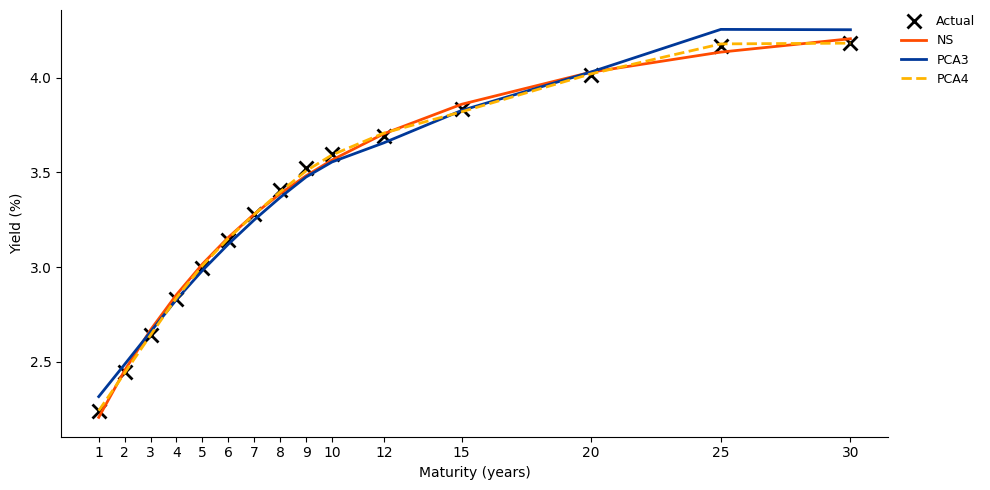


RMSE vs actual (2005-01-27):
  NS      0.0239 bp
  PCA3    0.0435 bp
  PCA4    0.0082 bp


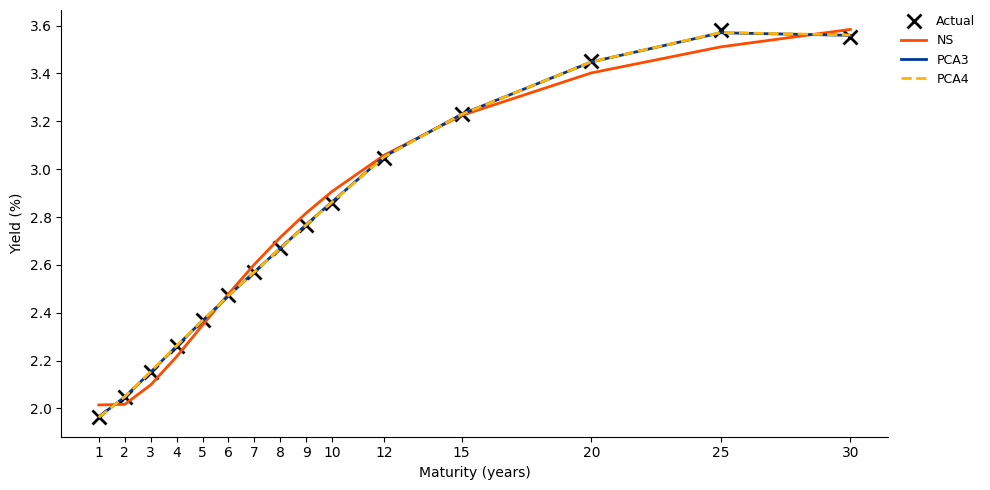


RMSE vs actual (2026-01-28):
  NS      0.0408 bp
  PCA3    0.0036 bp
  PCA4    0.0034 bp


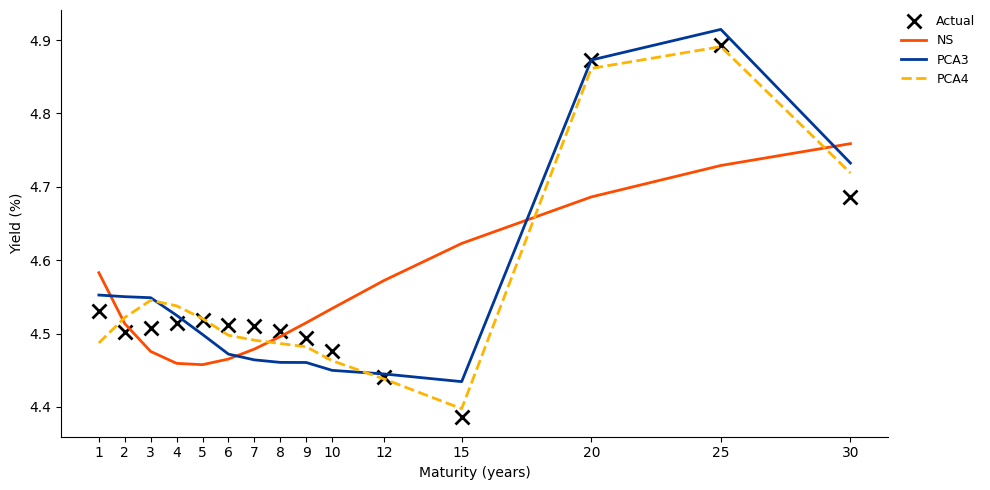


RMSE vs actual (2008-06-24):
  NS      0.1026 bp
  PCA3    0.0341 bp
  PCA4    0.0212 bp


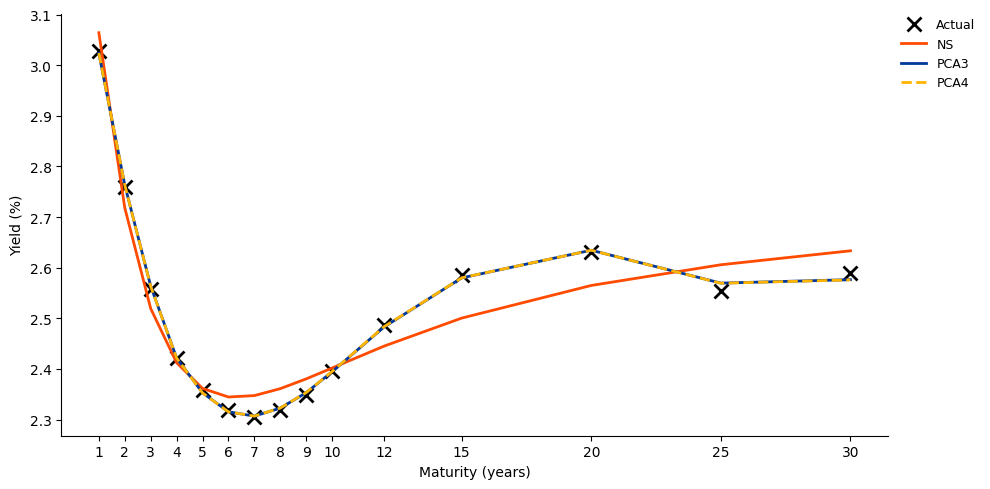


RMSE vs actual (2024-06-24):
  NS      0.0431 bp
  PCA3    0.0065 bp
  PCA4    0.0064 bp


In [23]:
plot_fit('2005-01-27')
plot_fit('2026-01-28') 
plot_fit('2008-06-24')
plot_fit('2024-06-24')  